In [5]:
# Cell 1 - Imports
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
import numpy as np
import matplotlib.pyplot as plt


In [8]:
# Cell 2 - Download SVHN from an alternative mirror
import urllib.request
import os

train_url = "https://cseweb.ucsd.edu/~weijian/static/datasets/svhn/train_32x32.mat"
test_url  = "https://cseweb.ucsd.edu/~weijian/static/datasets/svhn/test_32x32.mat"

train_file = "train_32x32.mat"
test_file = "test_32x32.mat"

if not os.path.exists(train_file):
    urllib.request.urlretrieve(train_url, train_file)

if not os.path.exists(test_file):
    urllib.request.urlretrieve(test_url, test_file)

print("SVHN dataset downloaded successfully!")

SVHN dataset downloaded successfully!


In [9]:
# Cell 3 - Load SVHN
train_data = loadmat(train_file)
test_data = loadmat(test_file)

x_train = train_data["X"]
y_train = train_data["y"]
x_test = test_data["X"]
y_test = test_data["y"]

print("Original train shape:", x_train.shape)
print("Original test shape :", x_test.shape)


Original train shape: (32, 32, 3, 73257)
Original test shape : (32, 32, 3, 26032)


In [10]:
# Cell 4 - Preprocess
x_train = np.transpose(x_train, (3, 0, 1, 2))
x_test = np.transpose(x_test, (3, 0, 1, 2))

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

# In SVHN, digit 0 is encoded as 10
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


x_train shape: (73257, 32, 32, 3)
x_test shape : (26032, 32, 32, 3)
y_train shape: (73257,)
y_test shape : (26032,)


In [11]:
# Cell 5 - One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


y_train shape: (73257, 10)
y_test shape : (26032, 10)


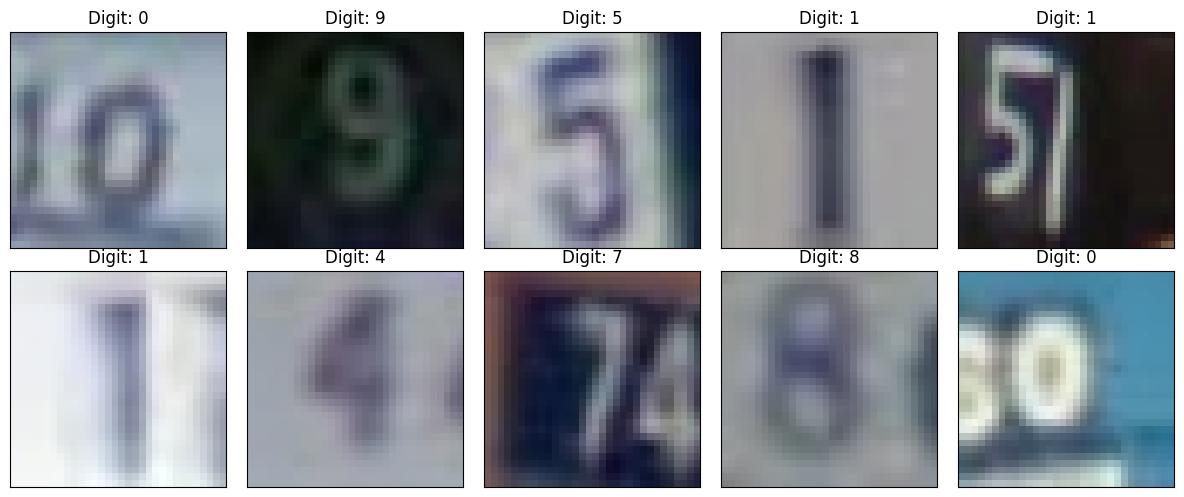

In [12]:
# Cell 6 - Show sample images
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]

plt.figure(figsize=(12, 5))
for i, j in enumerate(idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[j])
    plt.xticks([])
    plt.yticks([])
    plt.title("Digit: " + str(np.argmax(y_test[j])))

plt.tight_layout()
plt.show()


In [13]:
# Cell 7 - CNN
inpt_dim = (32, 32, 3)
inpt_img = Input(shape=inpt_dim)

c11 = Conv2D(64, (9, 9), strides=(2, 2), activation="relu")(inpt_img)
p12 = MaxPooling2D(pool_size=(2, 2))(c11)
bn13 = BatchNormalization()(p12)

c14 = Conv2D(128, (3, 3), strides=(1, 1), activation="relu")(bn13)
p15 = MaxPooling2D(pool_size=(2, 2))(c14)
bn16 = BatchNormalization()(p15)

f17 = Flatten()(bn16)
do18 = Dropout(0.5)(f17)
d19 = Dense(256, activation="relu")(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(64, activation="relu")(do110)
do112 = Dropout(0.1)(d111)

output = Dense(10, activation="sigmoid")(do112)
classifier = Model(inpt_img, output)


In [14]:
# Cell 8 - Compile
opt = RMSprop(learning_rate=0.001)

classifier.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(classifier.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 12, 12, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,666 (932.29 KB)

 Trainable params: 238,282 (930.79 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [16]:
# Cell 9 - Callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_delta=1e-4,
    mode="min",
    verbose=1
)

stop_alg = EarlyStopping(
    monitor="val_loss",
    patience=35,
    restore_best_weights=True,
    verbose=1
)

checkpoint_filepath = "svhn_cnn_best.keras"

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)


In [18]:
# Cell 10 - Training
hist = classifier.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=15,
    callbacks=[stop_alg, reduce_lr, model_checkpoint],
    shuffle=True,
    validation_split=0.1
)


Epoch 1/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8026 - loss: 0.1068 - val_accuracy: 0.8250 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 2/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8246 - loss: 0.0979 - val_accuracy: 0.8598 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 3/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8381 - loss: 0.0909 - val_accuracy: 0.8580 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 4/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8465 - loss: 0.0869 - val_accuracy: 0.8691 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 5/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8519 - loss: 0.0849 - val_accuracy: 0.8890 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 6/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8599 - loss: 0.0817 - val_accuracy: 0.8741 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 7/15
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8620 - 

In [22]:
# Fine-Tuning
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

classifier.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_checkpoint = ModelCheckpoint(
    "svhn_cnn_finetuned_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

fine_tune_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

fine_tune_history = classifier.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    shuffle=True,
    callbacks=[fine_tune_checkpoint, fine_tune_stop]
)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8886 - loss: 0.0645
Epoch 1: val_accuracy improved from None to 0.91127, saving model to svhn_cnn_finetuned_best.keras

Epoch 1: finished saving model to svhn_cnn_finetuned_best.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.8908 - loss: 0.0636 - val_accuracy: 0.9113 - val_loss: 0.0529
Epoch 2/10
126/129 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8936 - loss: 0.0625
Epoch 2: val_accuracy improved from 0.91127 to 0.91455, saving model to svhn_cnn_finetuned_best.keras

Epoch 2: finished saving model to svhn_cnn_finetuned_best.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8935 - loss: 0.0620 - val_accuracy: 0.9146 - val_loss: 0.0518
Epoch 3/10
126/129 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8944 - loss: 0.0606
Epoch 3: val_accuracy improved from 0.91455 to 0.91482, saving model to svhn_cnn_finetuned_best.keras

Epoch 3: finished saving model to svhn_cnn_finetuned_best.keras
129/1

In [23]:
# Evaluate fine-tuned model
test_loss, test_accuracy = classifier.evaluate(
    x_test,
    y_test,
    verbose=2
)

print(f"Fine-Tuned Test Loss: {test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {test_accuracy:.4f}")

814/814 - 3s - 3ms/step - accuracy: 0.9105 - loss: 0.0547
Fine-Tuned Test Loss: 0.0547
Fine-Tuned Test Accuracy: 0.9105


In [26]:
# Save fine-tuned model
classifier.save("svhn_cnn.keras")
print("Fine-tuned model saved successfully!")

Fine-tuned model saved successfully!


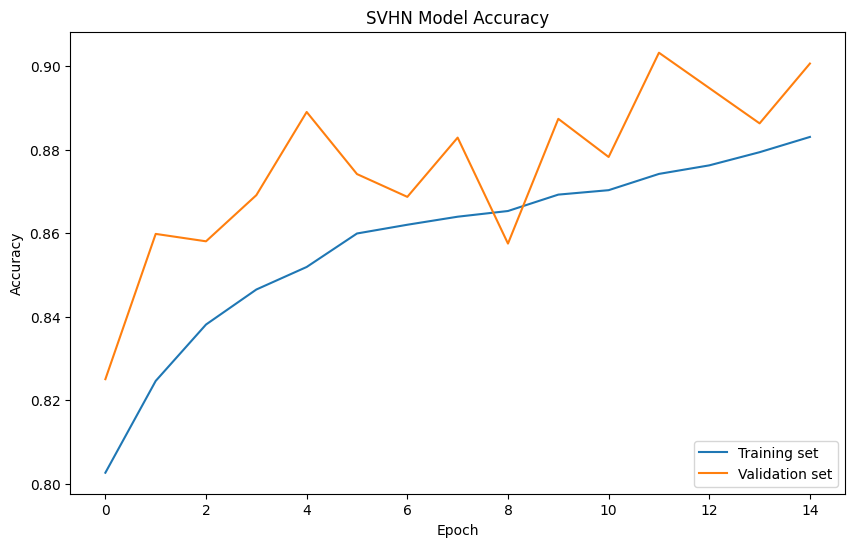

In [27]:
# Cell 11 - Accuracy
plt.figure(figsize=(10, 6))
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.title("SVHN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training set", "Validation set"], loc="lower right")
plt.show()


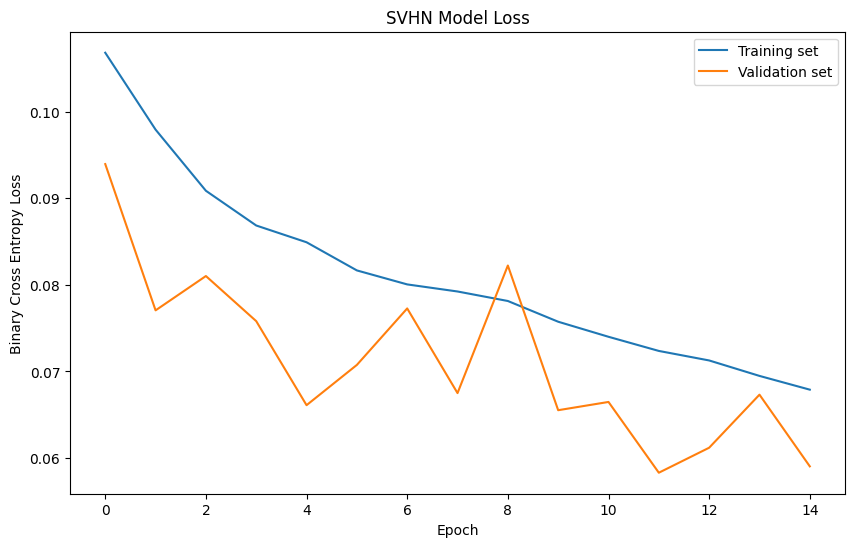

In [28]:
# Cell 12 - Loss
plt.figure(figsize=(10, 6))
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("SVHN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend(["Training set", "Validation set"], loc="upper right")
plt.show()


In [29]:
# Cell 13 - Test evaluation
test_loss, test_accuracy = classifier.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


814/814 - 2s - 3ms/step - accuracy: 0.9105 - loss: 0.0547
Test Loss: 0.0547
Test Accuracy: 0.9105


In [30]:
# Cell 14 - Classification report + confusion matrix + BER
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

y_hat = classifier.predict(x_test, verbose=0)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_hat, axis=1)

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(10)),
    target_names=[str(i) for i in range(10)]
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
print("Confusion Matrix:")
print(cm)

ber = 1 - balanced_accuracy_score(y_true, y_pred)
print(f"BER: {ber:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1744
           1       0.94      0.95      0.94      5099
           2       0.92      0.94      0.93      4149
           3       0.90      0.86      0.88      2882
           4       0.93      0.93      0.93      2523
           5       0.90      0.90      0.90      2384
           6       0.87      0.89      0.88      1977
           7       0.93      0.91      0.92      2019
           8       0.90      0.86      0.88      1660
           9       0.84      0.89      0.86      1595

    accuracy                           0.91     26032
   macro avg       0.90      0.90      0.90     26032
weighted avg       0.91      0.91      0.91     26032

Confusion Matrix:
[[1556   20   26   12    5    7   48   12   17   41]
 [  41 4839   37   24   63   13   17   48    9    8]
 [  10   31 3899   54   36   26   16   39   16   22]
 [  18   51   58 2481    7   74   28   12

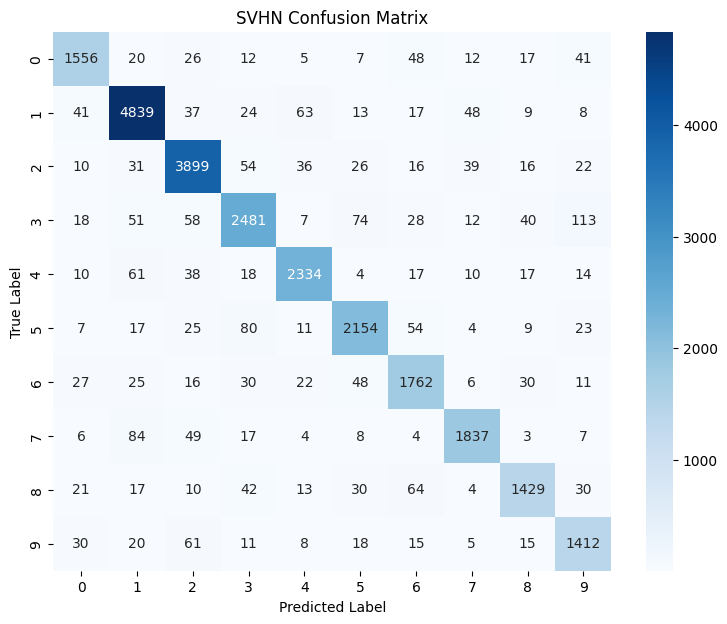

In [31]:
# Cell 15 - Confusion matrix visualization
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVHN Confusion Matrix")
plt.show()


In [32]:
# Cell 16 - Save model and weights
classifier.save("svhn_cnn.keras")
classifier.save_weights("svhn_cnn.weights.h5")

print("Model saved successfully!")
print("Full model   : svhn_cnn.keras")
print("Model weights: svhn_cnn.weights.h5")


Model saved successfully!
Full model   : svhn_cnn.keras
Model weights: svhn_cnn.weights.h5


In [33]:
# Cell 17 - Download model
from google.colab import files
files.download("svhn_cnn.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

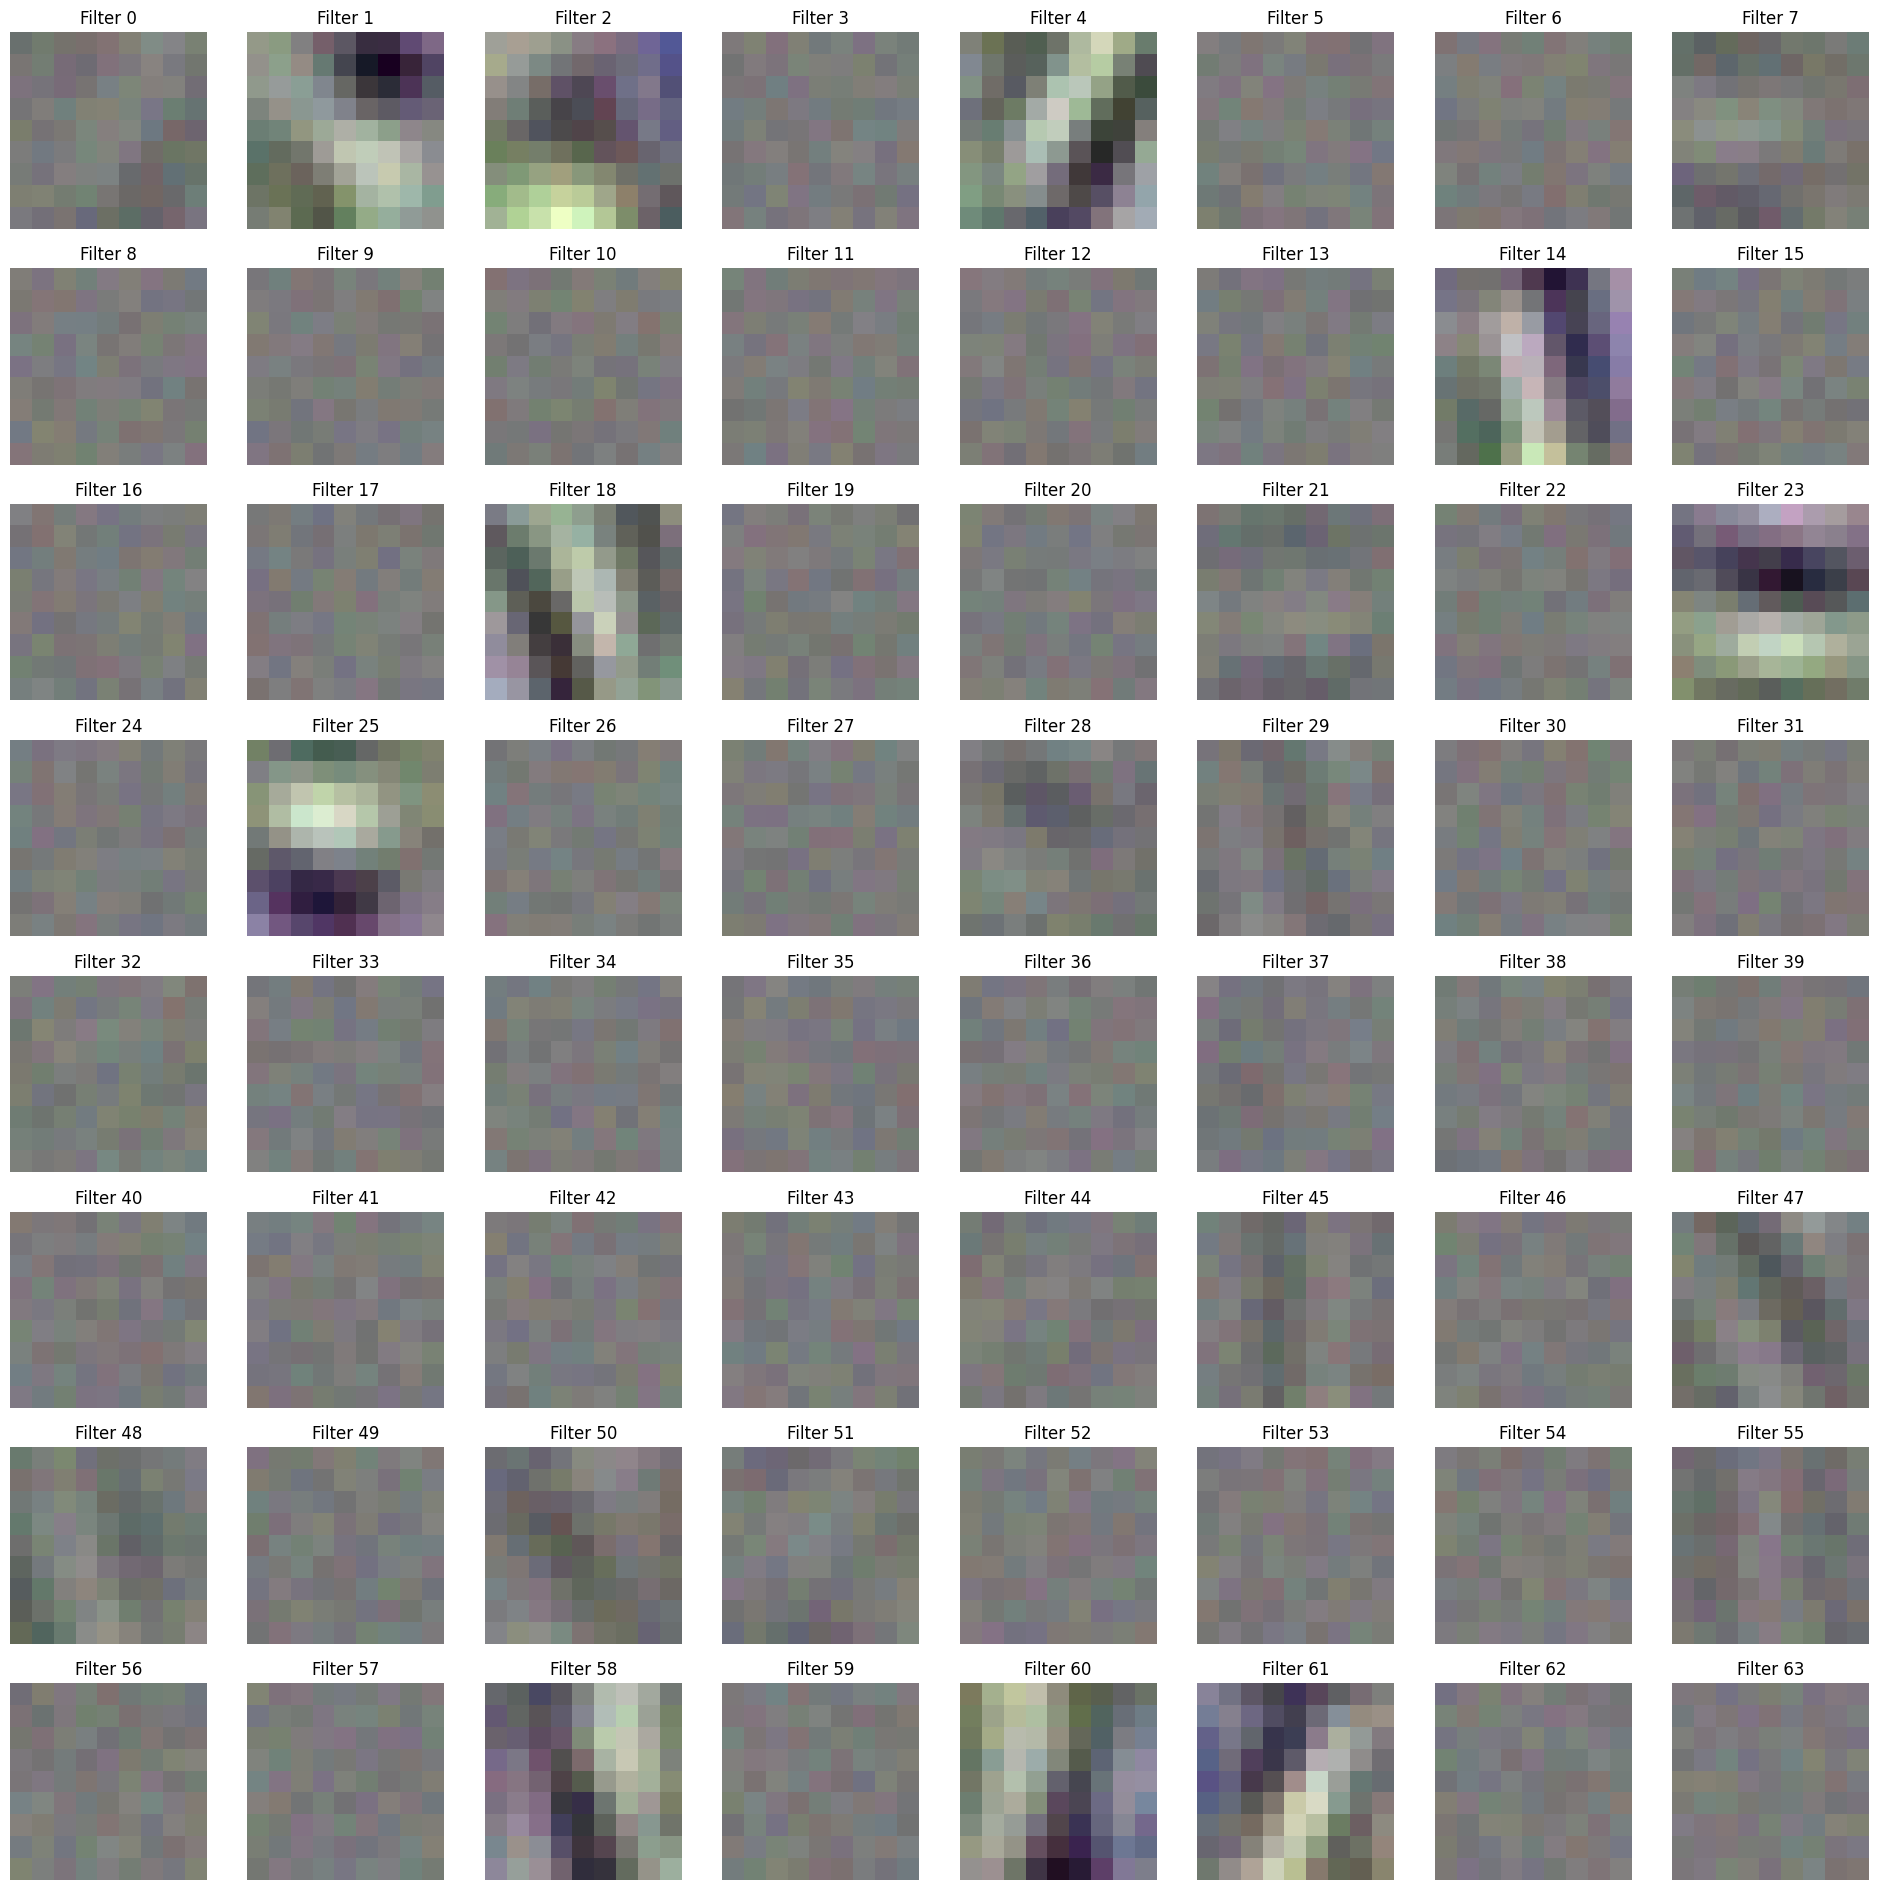

In [34]:
# Cell 18 - Visualize first convolution filters
from sklearn.preprocessing import MinMaxScaler

cnn11 = classifier.layers[1].name
w = classifier.get_layer(cnn11).get_weights()[0]
wshape = w.shape

scaler = MinMaxScaler()
scaler.fit(w.reshape(-1, 1))
w = scaler.transform(w.reshape(-1, 1)).reshape(wshape)

fig, axs = plt.subplots(8, 8, figsize=(24, 24))
axs = axs.ravel()

for i in range(min(w.shape[-1], 64)):
    h = np.reshape(w[:, :, :, i], (9, 9, 3))
    axs[i].imshow(h)
    axs[i].set_title("Filter " + str(i))
    axs[i].axis("off")

plt.show()
